# Évaluation & Comparaison finale

Objectif : comparer tous les modèles (classiques et MLP) sur les mêmes métriques.

In [1]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score

# ── 1. Chargement des données ─────────────────────────
with open('../data/processed_data.pkl', 'rb') as f:
    data = pickle.load(f)

X_test_scaled  = data['X_test_scaled']
y_test         = data['y_test']

# ── 2. Chargement des modèles classiques ──────────────
with open('../models/classical_models.pkl', 'rb') as f:
    classical_models = pickle.load(f)

lr = classical_models['logistic_regression']
dt = classical_models['decision_tree']
rf = classical_models['random_forest']

# ── 3. Chargement du modèle MLP et son seuil ──────────
mlp_model = tf.keras.models.load_model('../models/mlp_best.keras')

with open('../models/mlp_threshold.pkl', 'rb') as f:
    best_threshold = pickle.load(f)

print(f"✅ Tout est chargé. Seuil MLP : {best_threshold:.2f}")

✅ Tout est chargé. Seuil MLP : 0.85


17367/17367 ━━━━━━━━━━━━━━━━━━━━ 38s 2ms/step
                       Recall  Precision  F1-Score  AUC-ROC
Régression Logistique  0.7851     0.0303    0.0583   0.9408
Arbre de Décision      0.7105     0.0754    0.1363   0.7668
Random Forest          0.4429     0.9510    0.6043   0.9602
MLP (notre modèle)     0.8797     0.2659    0.4084   0.9947


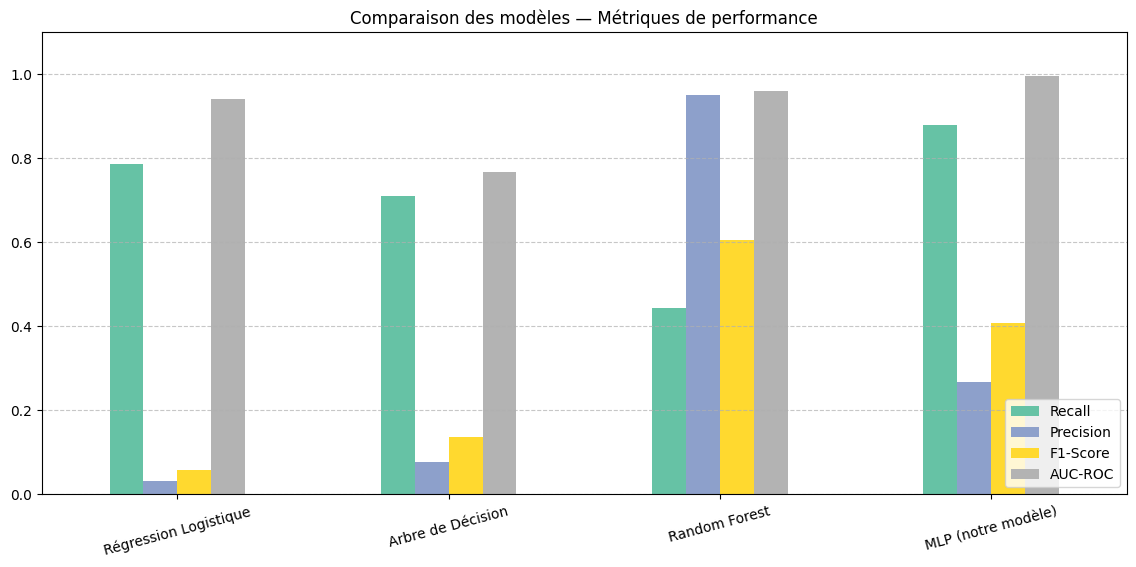

In [2]:
# ── Tableau comparatif ────────────────────────────────
models_results = {}

for name, mdl in [("Régression Logistique", lr),
                   ("Arbre de Décision", dt),
                   ("Random Forest", rf)]:
    y_pred = mdl.predict(X_test_scaled)
    y_prob = mdl.predict_proba(X_test_scaled)[:,1]
    models_results[name] = {
        'Recall':    recall_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'F1-Score':  f1_score(y_test, y_pred),
        'AUC-ROC':   roc_auc_score(y_test, y_prob)
    }

# MLP
y_prob_mlp = mlp_model.predict(X_test_scaled).flatten()
y_pred_mlp = (y_prob_mlp >= best_threshold).astype(int)

models_results["MLP (notre modèle)"] = {
    'Recall':    recall_score(y_test, y_pred_mlp),
    'Precision': precision_score(y_test, y_pred_mlp),
    'F1-Score':  f1_score(y_test, y_pred_mlp),
    'AUC-ROC':   roc_auc_score(y_test, y_prob_mlp)
}

comparison_df = pd.DataFrame(models_results).T
print(comparison_df.round(4))

# Visualisation comparative
comparison_df.plot(kind='bar', figsize=(14,6), colormap='Set2')
plt.title("Comparaison des modèles — Métriques de performance")
plt.xticks(rotation=15)
plt.ylim(0, 1.1)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()